In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from dreal import *
import matplotlib.patches as patches
from matplotlib import cm

In [2]:
import sys
import os

sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))

from Neural_Density_Training.Models import (
    Polynomial_net,
    Polynomial_net_bias_zero,
    Numerator_polynomial_net,
    GammaFunctionNet,
)
from Neural_Density_Training.loss import (
    stability_loss,
    invariance_loss,
    safety_loss,
)
from Neural_Density_Training.falsifier import checkSMTconstraints, AddCounterexamples
from Neural_Density_Training.extract_model import SymbolicNN, activSymbolicNN
from Neural_Density_Training.plotter import (
    plot_contour_density,
    plot_contour_mixed_density,
)

## Sample Data 

We will use seed to ensure the reproducibility

In [3]:

torch.cuda.empty_cache()
torch.manual_seed(17)
random.seed()

In [4]:

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Pre-allocate numerical_x
numerical_x = torch.Tensor(2000, 2).uniform_(-3, 3).float().to(device)


Using device: cpu


# Define the Dynamics:

In [5]:
v = 6.0
L = 1.0
kappa = 1.0


def f(x):
    """Vectorized path following dynamics f(x)- handles batched input"""
    if x.dim() == 1:
        x = x.unsqueeze(0)

    val = torch.stack(
        [ v * torch.sin(x[:,1])
            ,
            -1 * v * torch.cos(x[:,1]) / (1 - kappa * x[:,0])
         ], dim=1
    )
    return val.squeeze(0) if val.shape[0]== 1 else val

def g(x):
    if x.dim() == 1:
        x = x.unsqueeze(0)
    val = torch.stack(
        [
            torch.zeros_like(x[:,0]),
           v * torch.ones_like(x[:,1]) / L
         ], dim=1
    )
    return val.squeeze(0) if val.shape[0]== 1 else val

def div_f(x):
    """Vectorized divergence of f-handles batched input"""
    divergence = v * kappa * torch.sin(x[:,1]) / (1 - kappa * x[:,0])
    if x.dim() == 1:
        return divergence.squeeze(0)
    return divergence

def div_g(x):
    """Vectorized divergence of g-handles batched input"""
    if x.dim() == 1:
        return torch.tensor(0.0, device=device)
    else:
        return torch.zeros(x.shape[0], device=device)
    



# Describe the constraints

In [6]:
def candidate_constraint_learnt(vars,a_fun,b_fun,c_fun):
    """
    Construct candidate constraints for the learnt functions.
    
    Args:
        vars: List of dReal Variables
        a_fun: Function representing a(x).
        b_fun: Function representing b(x).
        c_fun: Function representing c(x).

    Returns:
        Symbolic expression for the candidate constraint.
    """
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]

    # b_sym = ||b_sym||^2
    b_sym = sum([bi**2 for bi in b_sym])


    # write f and g in terms of val
    v = 1.0  # speed
    kappa = 1.0  # curvature 
    L = 2.0  # length of the vehicle
    D = 1 - vars[0] * kappa  # D = 1 - d_e * kappa

    f_val = [
        v * sin(vars[1]),
        - (v * kappa * cos(vars[1])) / D
    ]
    g_val = [
        0,
        v / L
    ]

    f_div = (v * kappa * sin(vars[1])) / D
    g_div = 0



    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]

    constraint1 = a_sym * f_div + g_div * c_sym + sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + sum([grad_c[i] * g_val[i] for i in range(len(g_val))])
  
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]

    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) for i in range(len(f_val))])  
    constraint = constraint1 - constraint2
    return a_sym , constraint


In [7]:
def train_density(
    x,                          # initial sample tensor  [N, state_dim]
    f,                          # dynamics callable
    g,                          # control matrix callable
    div_f,                      # divergence of f callable
    div_g,                      # divergence of g callable
    device,
    # --- training ---
    epochs          = 2000,
    lr              = 1e-2,
    loss_threshold  = 5e-4,
    # --- SMT verification ---
    ball_lb         = 0.05,
    ball_ub         = 6.0,
    check_interval  = 10,
    n_counterex     = 100,
):
    
    # Instantiate neural networks for a, b, c, gamma
    a_net = Numerator_polynomial_net(layers=2, input_dim=2, hidden_dim=2, output_dim=1).to(device)
    b_net = Polynomial_net_bias_zero(layers=2, input_dim=2, hidden_dim=2, output_dim=1).to(device)
    c_net = Polynomial_net(layers=3, input_dim=2, hidden_dim=12, output_dim=1).to(device)
    gamma_net = GammaFunctionNet(input_dim=2,output_dim=1).to(device)

    
    # Loss and Optimizer
    criterion = stability_loss(f=f,g=g,div_f=div_f,div_g=div_g)

    optimizer = torch.optim.Adam(list(a_net.parameters()) +
                                    list(b_net.parameters()) + 
                                    list(c_net.parameters()) + 
                                    list(gamma_net.parameters()), lr=lr)
    
    # dReal Configuration
    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5   

    # CEGIS Loop
    loss_history = []
    valid = False 
    print("=" * 60)
    print("Training density function with SMT-CEGIS verification")
    print(f"  Initial dataset size: {x.shape[0]}")
    print("=" * 60)    

    while not valid:
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss = criterion(x, a_net, b_net, c_net, gamma_net)         
            loss_history.append(loss.item())
            loss.backward()
            optimizer.step()

            
            # ---------- early-exit on convergence ----------
            if loss.item() < loss_threshold:
                print(f"  [Epoch {epoch}] Loss {loss.item():.6f} < threshold to checking SMT...")
                valid = True
                break

            # ---------- periodic progress print ------------
            if epoch % 50 == 0:
                print(
                    f"  Epoch {epoch:>5}/{epochs} | "
                    f"Loss: {loss.item():.6f} | "
                    f"Dataset: {x.shape[0]}"
                )            
 
            # ---------- SMT counterexample check -----------
            if epoch % check_interval == 0 and epoch > 0:
                vars_sym = [Variable("x1"), Variable("x2")]
                try:
                    a_sym, div_sym = candidate_constraint_learnt(
                        vars_sym, a_net, b_net, c_net
                    )
                    CE = checkSMTconstraints(
                        vars_sym, a_sym, div_sym, ball_lb, ball_ub, config
                    )
 
                    if CE:
                        before = x.shape[0]
                        x, _ = AddCounterexamples(x, CE, n_counterex, device)
                        after = x.shape[0]
                        print(
                            f"  [Epoch {epoch}] CE found → "
                            f"dataset {before} → {after} (+{after - before})"
                        )
                    else:
                        valid = True
                        print(f"  [Epoch {epoch}] SMT satisfied — no counterexample found ✓")
                        break
 
                except Exception as e:
                    print(f"  [Epoch {epoch}] SMT check failed: {e}")
                    continue
 
    # ------------------------------------------------------------------
    # 5. Final summary
    # ------------------------------------------------------------------
    test_point = torch.zeros(1, 2, dtype=torch.float32, device=device)
    margin     = gamma_net(test_point).item()
 
    print("\n" + "=" * 60)
    print("Training complete")
    print(f"  Final loss     : {loss_history[-1]:.6f}")
    print(f"  Learned margin : {margin:.6f}")
    print(f"  Final dataset  : {x.shape[0]}")
    print("=" * 60)
 
    return loss_history, a_net, b_net, c_net, gamma_net
 

In [ ]:
print("=" * 60)
print("Path Tracking Density Training")
print("=" * 60)

loss_history1, a_net1, b_net1, c_net1, gamma_net1 = train_density(
    x=numerical_x,
    f=f,
    g=g,
    div_f=div_f,
    div_g=div_g,
    device=device,
    epochs=4000,
    lr=1e-3,
    loss_threshold=5e-4,
    ball_lb=0.5,
    ball_ub=3.0,
    check_interval=500,
    n_counterex=100
)

Path Tracking Density Training
Training density function with SMT-CEGIS verification
  Initial dataset size: 2000
  Epoch     0/4000 | Loss: 13.918079 | Dataset: 2000
  Epoch    50/4000 | Loss: 4.637133 | Dataset: 2000
  Epoch   100/4000 | Loss: 3.743973 | Dataset: 2000
  Epoch   150/4000 | Loss: 3.344937 | Dataset: 2000
  Epoch   200/4000 | Loss: 2.994157 | Dataset: 2000
  Epoch   250/4000 | Loss: 2.669090 | Dataset: 2000
  Epoch   300/4000 | Loss: 2.369775 | Dataset: 2000
  Epoch   350/4000 | Loss: 2.095448 | Dataset: 2000
  Epoch   400/4000 | Loss: 1.856547 | Dataset: 2000
  Epoch   450/4000 | Loss: 1.646435 | Dataset: 2000
  Epoch   500/4000 | Loss: 1.459532 | Dataset: 2000
  [Epoch 500] CE found → dataset 2000 → 2100 (+100)
  Epoch   550/4000 | Loss: 1.233777 | Dataset: 2100
  Epoch   600/4000 | Loss: 1.094774 | Dataset: 2100
  Epoch   650/4000 | Loss: 0.979153 | Dataset: 2100
  Epoch   700/4000 | Loss: 0.878118 | Dataset: 2100
  Epoch   750/4000 | Loss: 0.794055 | Dataset: 2100
 

In [ ]:
# Save the model to Models Folder. We are in experiments folder and Models is in the parent directory
model_path = "./Models/path_tracking_density_model.pth"
torch.save({
    'a_net_state_dict_path_tracking': a_net1.state_dict(),
    'b_net_state_dict_path_tracking': b_net1.state_dict(),
    'c_net_state_dict_path_tracking': c_net1.state_dict(),
}, model_path)
print(f"Model saved to {model_path}")

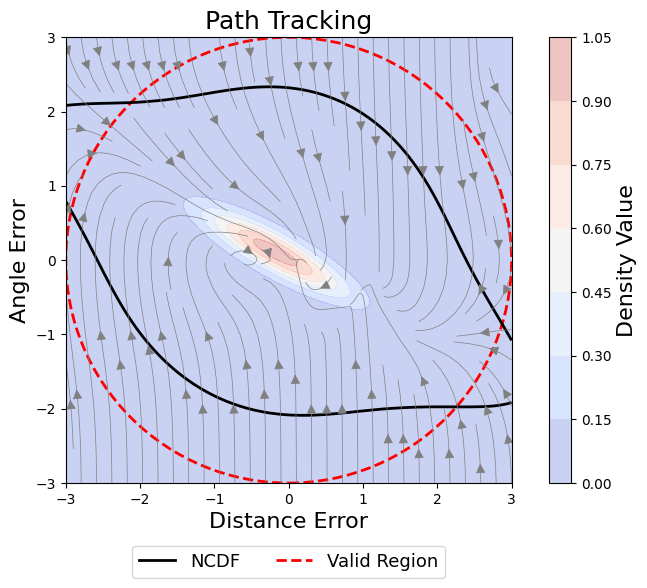

In [14]:
fig, ax = plot_contour_density(
    f=f,
    g=g,
    a=a_net1,
    b=b_net1,
    c=c_net1,
    x_lim = [-3,3],
    y_lim = [-3,3],
    density_threshold = 1e-6,
    title = "Path Tracking",
    x_axis_title="Distance Error", y_axis_title="Angle Error",
    device = device
)